# Credit Risk Predictor

**Goal:** Predict whether a loan applicant will default (binary classification) using financial history, demographics, and loan characteristics to support data-driven lending decisions.

**Data source:** [Kaggle Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset/data)

**Why it matters:** Loan defaults cost financial institutions billions annually. Identifying high-risk borrowers before approval protects assets while ensuring creditworthy applicants get fair access to credit.




## 1. Setup and Load Data

In [101]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay



In [102]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


data_path = Path("data/credit_risk_dataset.csv")
df = pd.read_csv(data_path)


In [103]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)

Shape: 32,581 rows × 12 columns


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


## 2. Exploratory Data Analysis (EDA) — Initial Report

Understand structure, types, missing values, and summary statistics.

In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [105]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_count", ascending=False)

,missing_count,missing_pct
loan_int_rate,3116,9.56
person_emp_length,895,2.75
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_status,0,0.00
loan_percent_income,0,0.00


In [106]:

df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [107]:
# Categorical variables
warnings.filterwarnings("ignore", category=FutureWarning)
cat_cols = df.select_dtypes(include=["object","string"]).columns.tolist()
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


person_home_ownership:
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent:
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade:
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file:
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [108]:
# Target distribution (loan_status: 0 = no default, 1 = default)
target_counts = df["loan_status"].value_counts()
print("loan_status (target):")
print(target_counts)
print(f"\nDefault rate: {df['loan_status'].mean():.2%}")

loan_status (target):
loan_status
0    25473
1     7108
Name: count, dtype: int64

Default rate: 21.82%


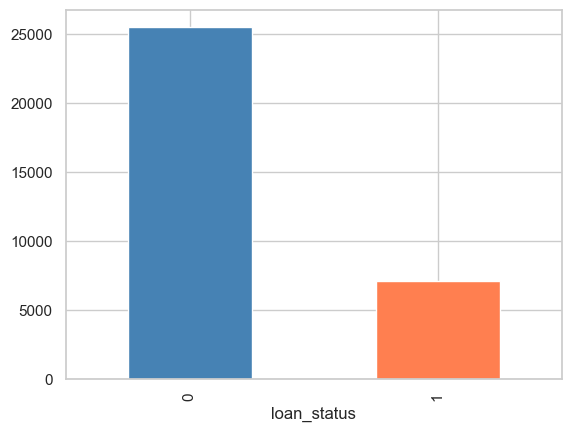

In [124]:
df["loan_status"].value_counts().plot(kind="bar",color=["steelblue","coral"])
plt.savefig('images/loan_status_distribution')

## 3. Data Cleaning

Handle missing values, invalid/outlier values, and type corrections.

In [125]:
df_clean = df.copy()

#  Missing loan_int_rate: impute with median by loan_grade (rate correlates with grade)
df_clean["loan_int_rate"] = df_clean["loan_int_rate"].astype(float)
median_rate_by_grade = df_clean.groupby("loan_grade")["loan_int_rate"].transform("median")
df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(median_rate_by_grade)

# person_emp_length: cap at 40 years (values like 123 are likely data errors)
df_clean["person_emp_length"] = df_clean["person_emp_length"].clip(upper=40)

# Drop any remaining rows with missing critical fields (if any)
before = len(df_clean)
df_clean = df_clean.dropna(subset=["person_emp_length", "loan_int_rate"])
print(f"Dropped {before - len(df_clean)} rows with missing values. Shape: {df_clean.shape}")

Dropped 895 rows with missing values. Shape: (31686, 12)


In [126]:
# Outlier check for income and loan amount
for col in ["person_income", "loan_amnt"]:
    q99 = df_clean[col].quantile(0.99)
    n_above = (df_clean[col] > q99).sum()
    print(f"{col}: 99th percentile = {q99:,.0f}, rows above = {n_above}")




person_income: 99th percentile = 228,000, rows above = 315
loan_amnt: 99th percentile = 30,000, rows above = 217


## 4. Feature Engineering and Variable Relationships

Derive new features and explore relationships beyond raw variables.

In [127]:
# Derived features
df_clean["income_to_loan_ratio"] = df_clean["person_income"] / (df_clean["loan_amnt"] + 1)
df_clean["debt_burden_high"] = (df_clean["loan_percent_income"] > 0.4).astype(int)
df_clean["cb_person_default_on_file_int"] = (df_clean["cb_person_default_on_file"] == "Y").astype(int)
# Loan grade as ordered risk (A=0 .. F=5) via ordinal encoding

grade_categories = [["A", "B", "C", "D", "E", "F","G"]]
enc = OrdinalEncoder(categories=grade_categories)
grade_col = df_clean["loan_grade"]
mask = grade_col.notna()
df_clean["loan_grade_ord"] = -1
df_clean.loc[mask, "loan_grade_ord"] = enc.fit_transform(grade_col[mask].to_frame()).ravel().astype(int)
df_clean[["income_to_loan_ratio", "debt_burden_high", "cb_person_default_on_file_int", "loan_grade_ord"]].describe()

,income_to_loan_ratio,debt_burden_high,cb_person_default_on_file_int,loan_grade_ord
count,31686.000000,31686.000000,31686.000000,31686.000000
mean,9.778682,0.033516,0.177649,1.226662
std,15.001260,0.179983,0.382223,1.168090
min,1.204747,0.000000,0.000000,0.000000
25%,4.374953,0.000000,0.000000,0.000000
50%,6.795609,0.000000,0.000000,1.000000
75%,11.196001,0.000000,0.000000,2.000000
max,1265.822785,1.000000,1.000000,6.000000


In [128]:
# Correlation of numeric features with target
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = df_clean[numeric_cols].corr()["loan_status"].drop("loan_status").sort_values(key=abs, ascending=False)
print("Correlation with loan_status (default):")
print(corr_with_target.to_string())

Correlation with loan_status (default):
loan_percent_income              0.379944
loan_grade_ord                   0.377022
loan_int_rate                    0.337951
debt_burden_high                 0.241504
cb_person_default_on_file_int    0.181233
person_income                   -0.140411
income_to_loan_ratio            -0.118264
loan_amnt                        0.112326
person_emp_length               -0.085389
person_age                      -0.023054
cb_person_cred_hist_length      -0.016889


In [129]:
# Default rate by categorical variables
for col in ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]:
    rate = df_clean.groupby(col)["loan_status"].agg(["mean", "count"])
    rate.columns = ["default_rate", "count"]
    rate = rate.sort_values("default_rate", ascending=False)
    print(f"\n{col}:")
    print(rate.round(4).to_string())


person_home_ownership:
                       default_rate  count
person_home_ownership                     
RENT                         0.3108  16076
OTHER                        0.3084    107
MORTGAGE                     0.1245  13093
OWN                          0.0693   2410

loan_intent:
                   default_rate  count
loan_intent                           
DEBTCONSOLIDATION        0.2838   5064
MEDICAL                  0.2654   5897
HOMEIMPROVEMENT          0.2556   3510
PERSONAL                 0.1950   5369
EDUCATION                0.1695   6290
VENTURE                  0.1465   5556

loan_grade:
            default_rate  count
loan_grade                     
G                 0.9844     64
F                 0.7034    236
E                 0.6418    952
D                 0.5877   3556
C                 0.2030   6321
B                 0.1592  10186
A                 0.0956  10371

cb_person_default_on_file:
                           default_rate  count
cb_person_defaul

## 5. Visualizations

Charts to interpret distributions, correlations, and default risk by key variables.

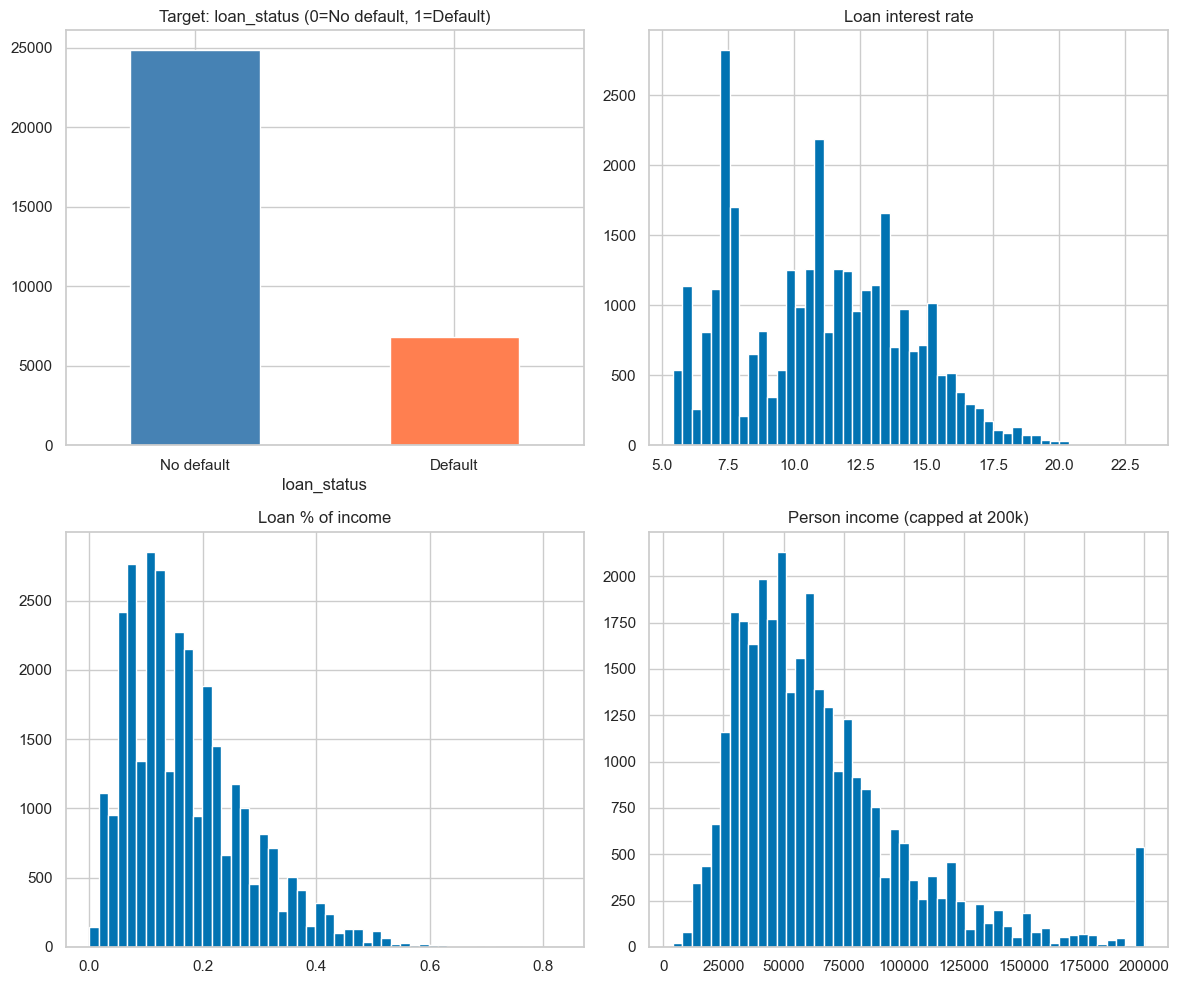

In [131]:

sns.set_theme(style="whitegrid", palette="colorblind")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Target balance
df_clean["loan_status"].value_counts().plot(kind="bar", ax=axes[0, 0], color=["steelblue", "coral"])
axes[0, 0].set_title("Target: loan_status (0=No default, 1=Default)")
axes[0, 0].set_xticklabels(["No default", "Default"], rotation=0)

# Numeric distributions (sample)
df_clean["loan_int_rate"].hist(bins=50, ax=axes[0, 1], edgecolor="white")
axes[0, 1].set_title("Loan interest rate")

df_clean["loan_percent_income"].hist(bins=50, ax=axes[1, 0], edgecolor="white")
axes[1, 0].set_title("Loan % of income")

df_clean["person_income"].clip(upper=200_000).hist(bins=50, ax=axes[1, 1], edgecolor="white")
axes[1, 1].set_title("Person income (capped at 200k)")

plt.tight_layout()
plt.savefig('images/numeric_distributions')

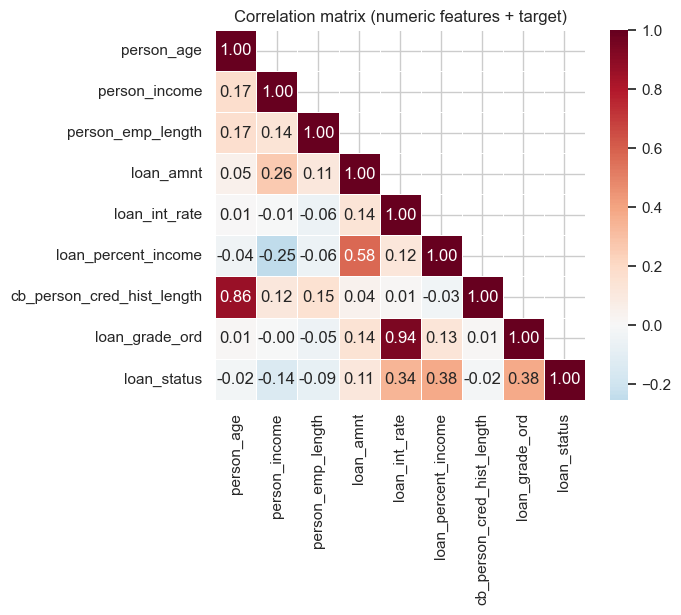

In [132]:
# Correlation heatmap (numeric)
num_subset = [
    "person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate",
    "loan_percent_income", "cb_person_cred_hist_length", "loan_grade_ord", "loan_status"
]
corr = df_clean[num_subset].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title("Correlation matrix (numeric features + target)")
plt.savefig('images/correlation_matrix')

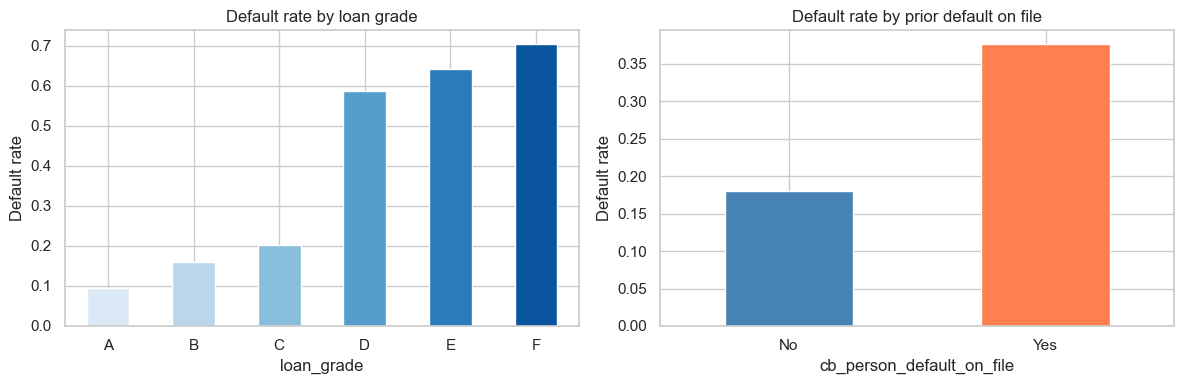

In [133]:
# Default rate by loan_grade and by previous default
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rate_grade = df_clean.groupby("loan_grade")["loan_status"].mean().reindex(["A", "B", "C", "D", "E", "F"])
rate_grade.plot(kind="bar", ax=axes[0], color=sns.color_palette("Blues", 6))
axes[0].set_title("Default rate by loan grade")
axes[0].set_ylabel("Default rate")
axes[0].set_xticklabels(rate_grade.index, rotation=0)

df_clean.groupby("cb_person_default_on_file")["loan_status"].mean().plot(kind="bar", ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Default rate by prior default on file")
axes[1].set_ylabel("Default rate")
axes[1].set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.savefig('images/default_rate_by_loan_grade')

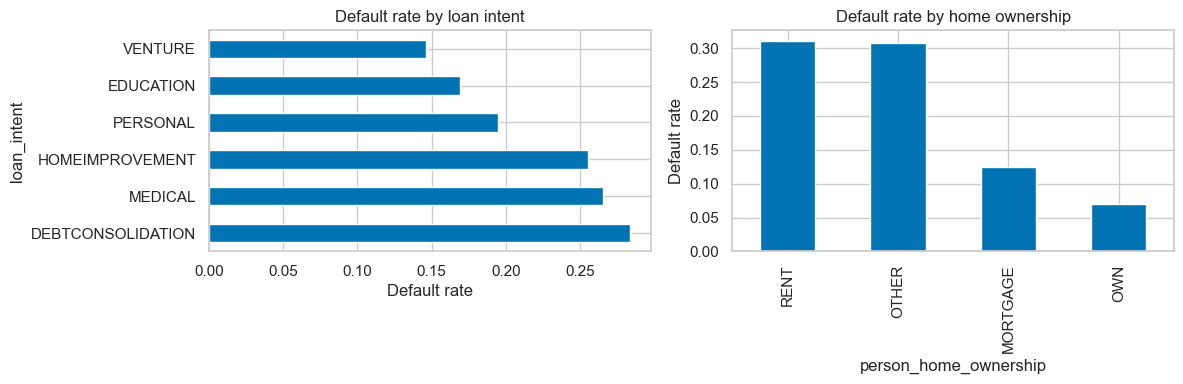

In [134]:
# Default rate by loan intent and home ownership
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean.groupby("loan_intent")["loan_status"].mean().sort_values(ascending=False).plot(kind="barh", ax=axes[0])
axes[0].set_title("Default rate by loan intent")
axes[0].set_xlabel("Default rate")

df_clean.groupby("person_home_ownership")["loan_status"].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[1])
axes[1].set_title("Default rate by home ownership")
axes[1].set_ylabel("Default rate")
plt.tight_layout()
plt.savefig('images/default_rate_by_loan_intent_and_home_ownership')

## 6. Baseline Model

Train a simple classifier and evaluate with accuracy, precision, recall, F1, and ROC-AUC.

In [135]:

# Target and feature split
target_col = "loan_status"
cat_features = ["person_home_ownership", "loan_intent", "loan_grade"]
num_features = [
    "person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate",
    "loan_percent_income", "cb_person_cred_hist_length", "income_to_loan_ratio",
    "debt_burden_high", "cb_person_default_on_file_int", "loan_grade_ord"
]
# Use numeric only for baseline (include ordinal and binary derived)
X = df_clean[num_features]
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 23764, Test: 7922


In [136]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")
baseline.fit(X_train_s, y_train)
y_pred = baseline.predict(X_test_s)
y_proba = baseline.predict_proba(X_test_s)[:, 1]

print("Baseline model (Logistic Regression) — Test set metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")


Baseline model (Logistic Regression) — Test set metrics:
  Accuracy:  0.7862
  Precision: 0.5025
  Recall:    0.7704
  F1:        0.6082
  ROC-AUC:   0.8463


In [137]:
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion matrix:
[[4913 1302]
 [ 392 1315]]


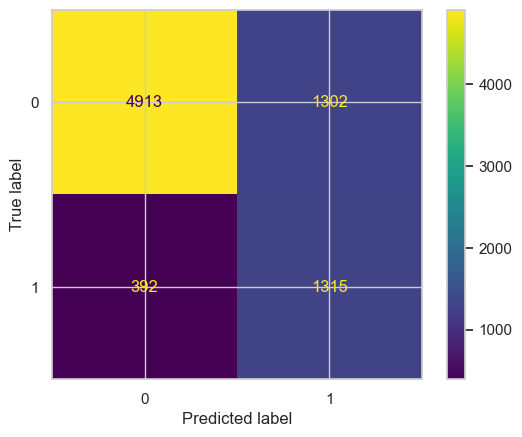

In [139]:
# plot confusion matrix
ConfusionMatrixDisplay.from_estimator(baseline, X_test_s, y_test)
plt.savefig('images/confusion_matrix')

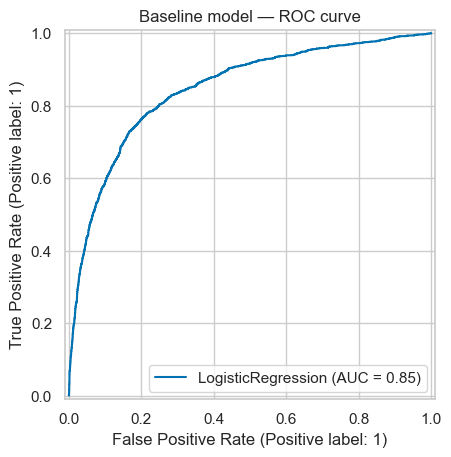

In [140]:
# ROC curve
RocCurveDisplay.from_estimator(baseline, X_test_s, y_test)
plt.title("Baseline model — ROC curve")
plt.savefig('images/roc_curve')

## 7. Summary

- **EDA:** Explored 32k+ rows; cleaned missing `loan_int_rate` (median by grade), capped `person_emp_length`; added features (income-to-loan ratio, debt burden, grade ordinal).
- **Findings:** Default rate varies by loan grade, prior default flag, loan intent, and home ownership; `loan_percent_income` and `loan_int_rate` correlate with default.
- **Baseline:** Logistic Regression (scaled numeric + derived features) gives a test-set benchmark for accuracy, precision, recall, F1, and ROC-AUC. Next: add categorical encoding, try Decision Tree, KNN, SVM, and tune with cross-validation and grid search.